# Phase 9: Improved Retention Model (Leakage-Free)

### Why this notebook exists

The Phase 7 churn model defines churn as `Recency > 180 days AND Frequency <= 2 orders`,
then predicts that same label using `Recency`, `Frequency`, and `Monetary`. Because the
label is built from two of the three inputs, that model scores near-perfectly — it's
faithfully re-deriving a rule, not forecasting real future behavior.

This notebook builds a genuinely predictive alternative:

- **Features** come only from a customer's **first order** (delivery experience, review
  score, payment method, price, product category, seasonality) — nothing that requires
  hindsight about their whole purchase history.
- **Label** is a real future event: did the customer place a **second order within 90 days**
  of their first one? Only customers whose first order was at least 90 days before the
  dataset's cutoff are included, so everyone had a fair chance to reorder.

This is a much harder problem — and a much more honest one.

### 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

%matplotlib inline

orders = pd.read_csv("../data/processed/orders_features.csv")
reviews = pd.read_csv("../data/processed/reviews_clean.csv")
payments = pd.read_csv("../data/processed/payments_clean.csv")
order_items = pd.read_csv("../data/processed/order_items_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
print("Orders:", orders.shape)

Orders: (99441, 14)


### 2. Build the Repeat-Purchase Label

In [2]:
REPEAT_WINDOW_DAYS = 90

orders_sorted = orders.sort_values(["customer_unique_id", "order_purchase_timestamp"])
orders_sorted["order_rank"] = orders_sorted.groupby("customer_unique_id").cumcount() + 1

first = orders_sorted[orders_sorted["order_rank"] == 1][
    ["customer_unique_id", "order_id", "order_purchase_timestamp"]
].rename(columns={"order_id": "first_order_id", "order_purchase_timestamp": "first_order_date"})

second = orders_sorted[orders_sorted["order_rank"] == 2][
    ["customer_unique_id", "order_purchase_timestamp"]
].rename(columns={"order_purchase_timestamp": "second_order_date"})

labels = first.merge(second, on="customer_unique_id", how="left")
labels["days_to_second_order"] = (labels["second_order_date"] - labels["first_order_date"]).dt.days
labels["repeat_within_90"] = (labels["days_to_second_order"] <= REPEAT_WINDOW_DAYS).fillna(False).astype(int)

# Only keep customers whose first order had at least 90 days of runway before the dataset's cutoff
reference_date = orders["order_purchase_timestamp"].max()
cutoff = reference_date - pd.Timedelta(days=REPEAT_WINDOW_DAYS)
labels = labels[labels["first_order_date"] <= cutoff].copy()

print(f"Eligible customers: {len(labels):,}")
print(f"Repeat-within-90-days rate: {labels['repeat_within_90'].mean() * 100:.2f}%")

Eligible customers: 86,924
Repeat-within-90-days rate: 2.26%


**First business insight, before any modeling:** only about 2% of customers who had a fair
90-day window to reorder actually did. Repeat purchase on this marketplace is rare — this
alone should shape strategy more than any classifier's predictions.

### 3. Build First-Order Features

In [3]:
df = labels.merge(
    orders[["order_id", "delivery_days", "late_delivery", "delivery_difference_days",
            "approval_time_hours", "order_value"]],
    left_on="first_order_id", right_on="order_id", how="left"
)

# Review score for the first order
review_score = reviews.groupby("order_id")["review_score"].mean().reset_index()
df = df.merge(review_score, left_on="first_order_id", right_on="order_id", how="left", suffixes=("", "_rev"))
df["review_score"] = df["review_score"].fillna(df["review_score"].median())

# Payment method
pay = (
    payments.sort_values("payment_sequential")
    .groupby("order_id").first()[["payment_type", "payment_installments"]]
    .reset_index()
)
df = df.merge(pay, left_on="first_order_id", right_on="order_id", how="left", suffixes=("", "_pay"))

# Product category + price/freight
items = order_items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
item_agg = items.groupby("order_id").agg(
    avg_price=("price", "mean"), avg_freight=("freight_value", "mean"), n_items=("product_id", "count")
).reset_index()
top_category = (
    items.groupby("order_id")["product_category_name"]
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else "unknown")
    .reset_index().rename(columns={"product_category_name": "category"})
)
df = df.merge(item_agg, left_on="first_order_id", right_on="order_id", how="left", suffixes=("", "_items"))
df = df.merge(top_category, left_on="first_order_id", right_on="order_id", how="left", suffixes=("", "_cat"))

top_categories = df["category"].value_counts().head(10).index
df["category"] = df["category"].where(df["category"].isin(top_categories), "other")

df["purchase_month"] = df["first_order_date"].dt.month
df["purchase_dayofweek"] = df["first_order_date"].dt.dayofweek

df = df.drop(columns=[c for c in df.columns if c.startswith("order_id")], errors="ignore")
df = df.fillna({
    "delivery_days": df["delivery_days"].median(),
    "delivery_difference_days": df["delivery_difference_days"].median(),
    "approval_time_hours": df["approval_time_hours"].median(),
    "avg_price": df["avg_price"].median(),
    "avg_freight": df["avg_freight"].median(),
    "payment_installments": 1,
})
df["payment_type"] = df["payment_type"].fillna("unknown")
df["late_delivery"] = df["late_delivery"].astype(str).map({"True": 1, "False": 0}).fillna(0)

df.head()

,customer_unique_id,first_order_id,first_order_date,second_order_date,days_to_second_order,repeat_within_90,delivery_days,late_delivery,delivery_difference_days,approval_time_hours,order_value,review_score,payment_type,payment_installments,avg_price,avg_freight,n_items,category,purchase_month,purchase_dayofweek
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27,NaT,NaN,0,6.0,0,-5.0,0.247500,141.90,5.0,credit_card,8.0,129.90,12.00,1.0,cama_mesa_banho,5,3
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27,NaT,NaN,0,3.0,0,-5.0,7.238056,27.19,4.0,credit_card,1.0,18.90,8.29,1.0,beleza_saude,5,0
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03,NaT,NaN,0,25.0,0,-2.0,0.000000,86.22,3.0,credit_card,8.0,69.00,17.22,1.0,other,3,4
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41,NaT,NaN,0,20.0,0,-12.0,0.326667,43.62,4.0,credit_card,4.0,25.99,17.63,1.0,telefonia,10,3
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42,NaT,NaN,0,13.0,0,-8.0,0.352778,196.89,5.0,credit_card,6.0,180.00,16.89,1.0,telefonia,11,1


### 4. Descriptive Insights (before modeling)

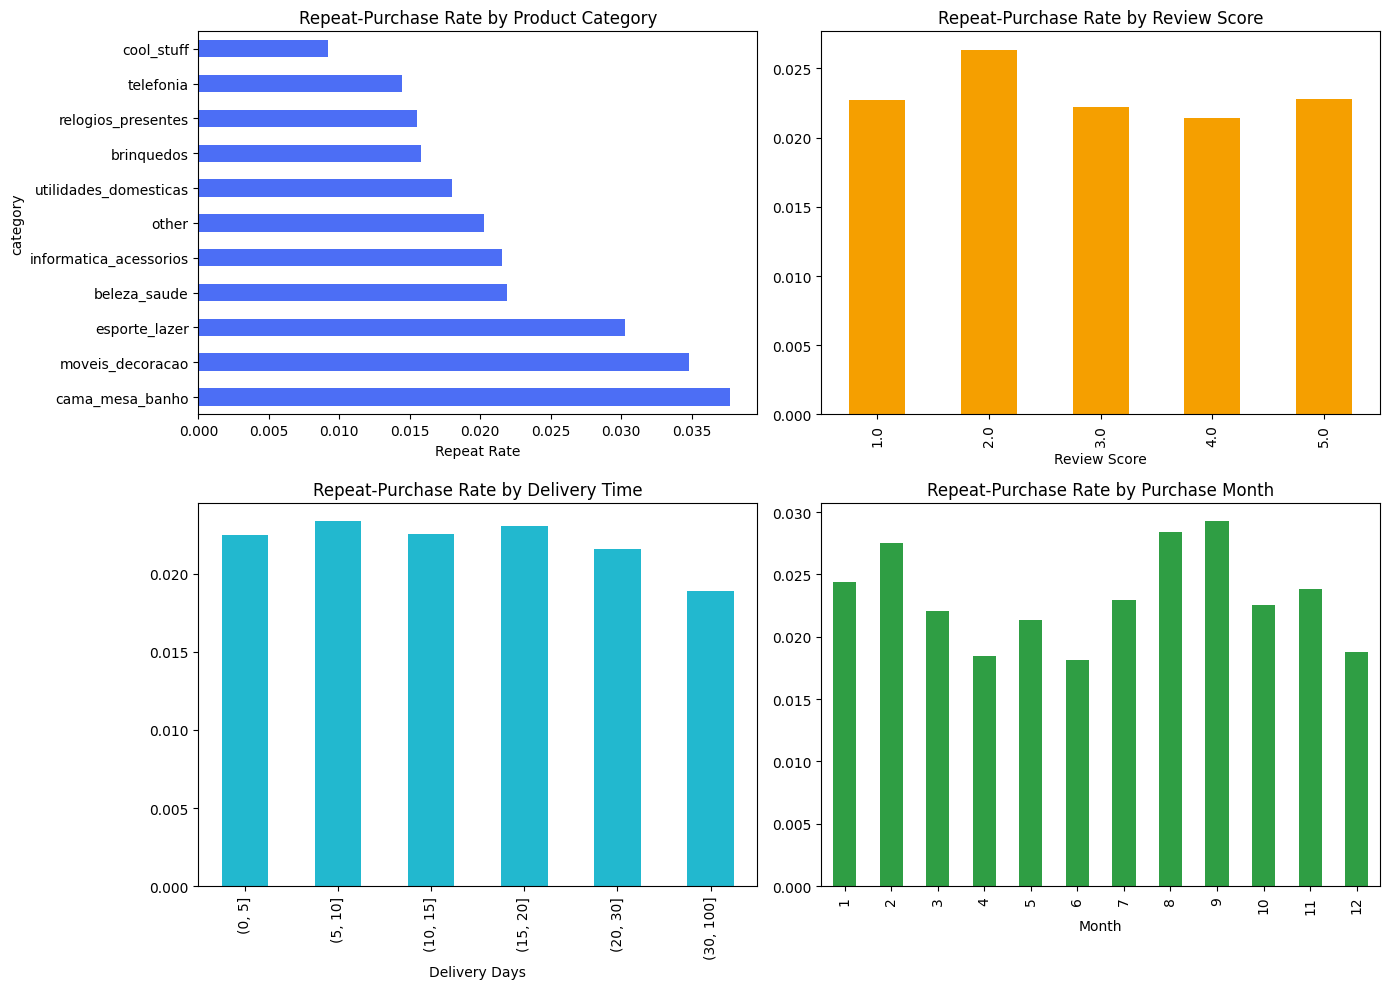

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby("category")["repeat_within_90"].mean().sort_values(ascending=False).plot(
    kind="barh", ax=axes[0,0], color="#4C6EF5"
)
axes[0,0].set_title("Repeat-Purchase Rate by Product Category")
axes[0,0].set_xlabel("Repeat Rate")

df.groupby(df["review_score"].round())["repeat_within_90"].mean().plot(
    kind="bar", ax=axes[0,1], color="#F59F00"
)
axes[0,1].set_title("Repeat-Purchase Rate by Review Score")
axes[0,1].set_xlabel("Review Score")

delivery_bins = pd.cut(df["delivery_days"], bins=[0,5,10,15,20,30,100])
df.groupby(delivery_bins)["repeat_within_90"].mean().plot(
    kind="bar", ax=axes[1,0], color="#22B8CF"
)
axes[1,0].set_title("Repeat-Purchase Rate by Delivery Time")
axes[1,0].set_xlabel("Delivery Days")

df.groupby("purchase_month")["repeat_within_90"].mean().plot(
    kind="bar", ax=axes[1,1], color="#2F9E44"
)
axes[1,1].set_title("Repeat-Purchase Rate by Purchase Month")
axes[1,1].set_xlabel("Month")

plt.tight_layout()
plt.show()

**Reading these charts:**
- **Category dominates.** Home/decor categories (`cama_mesa_banho` - bed/bath/table, `moveis_decoracao` - furniture/decor) see meaningfully higher repeat rates than gift/gadget categories (`cool_stuff`, `telefonia`). This suggests repeat purchase is driven more by *what* a customer buys than by *how well the first order went*.
- **Review score barely moves the needle.** Counter to intuition, a 1-star first review doesn't clearly predict a lower repeat rate here. This likely reflects the marketplace structure: Olist customers are buying from many independent sellers, so a bad experience with one seller doesn't necessarily sour them on the platform as a whole.
- **Delivery speed has a similar weak effect** — again likely because customers are shopping the *platform*, not a single retailer, so one slow delivery doesn't obviously deter a future purchase from a different seller/category.
- **Seasonality exists but is modest** — repeat rates dip slightly in April/June/December, rise slightly in Aug/Sep/Feb, plausibly tied to Brazilian retail calendar effects (mid-year lull, back-to-school, etc.), though the sample per month is not huge.

### 5. Train the Model

In [5]:
NUMERIC_FEATURES = [
    "delivery_days", "late_delivery", "delivery_difference_days", "approval_time_hours",
    "order_value", "review_score", "payment_installments", "avg_price", "avg_freight",
    "n_items", "purchase_month", "purchase_dayofweek",
]
CATEGORICAL_FEATURES = ["payment_type", "category"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
cat_encoded = encoder.fit_transform(df[CATEGORICAL_FEATURES])
cat_names = encoder.get_feature_names_out(CATEGORICAL_FEATURES)

X = np.hstack([df[NUMERIC_FEATURES].values, cat_encoded])
feature_names = NUMERIC_FEATURES + list(cat_names)
y = df["repeat_within_90"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced", random_state=42
)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Repeat", "Repeat"]))

ROC-AUC: 0.606

              precision    recall  f1-score   support

   No Repeat       0.98      0.84      0.91     16992
      Repeat       0.04      0.28      0.07       393

    accuracy                           0.83     17385
   macro avg       0.51      0.56      0.49     17385
weighted avg       0.96      0.83      0.89     17385



**Reading these numbers:** ROC-AUC of ~0.60 is modest — meaningfully better than a coin
flip (0.50), nowhere near the suspicious 1.00 from the rule-based model. Given the label is
a rare event (~2% positive rate) driven mostly by product category rather than the first
purchase's individual attributes, this is a believable result for a model with only
first-order features to work with. Precision on the "Repeat" class is low by construction
of `class_weight="balanced"` favoring recall over precision on a rare class — useful for
ranking/prioritization (see the probability scores), not for a hard yes/no cutoff.

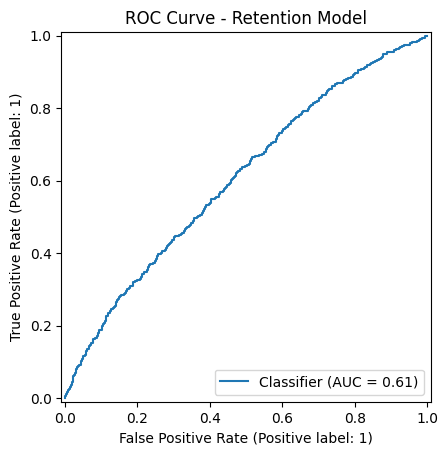

In [6]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Retention Model")
plt.show()

### 6. Feature Importance

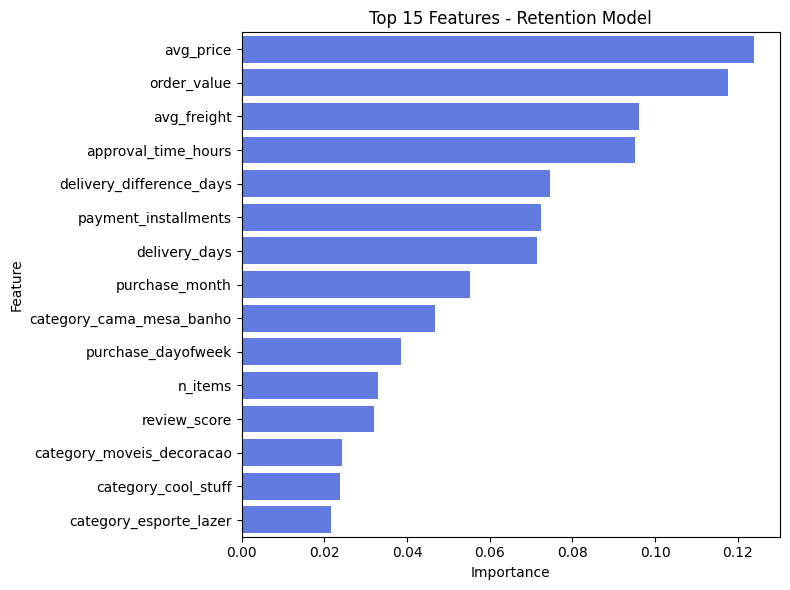

,Feature,Importance
7,avg_price,0.123989
4,order_value,0.117710
8,avg_freight,0.096217
3,approval_time_hours,0.095032
2,delivery_difference_days,0.074666
6,payment_installments,0.072420
0,delivery_days,0.071329
10,purchase_month,0.055308
19,category_cama_mesa_banho,0.046871
11,purchase_dayofweek,0.038651


In [7]:
importance_df = pd.DataFrame({
    "Feature": feature_names, "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", color="#4C6EF5")
plt.title("Top 15 Features - Retention Model")
plt.tight_layout()
plt.show()

importance_df

### 7. Save Scored Data for the Dashboard

In [8]:
df["Repeat_Probability"] = model.predict_proba(X)[:, 1]

df.to_csv("../data/processed/retention_model_features.csv", index=False)
df.to_csv("../data/processed/retention_model_scored.csv", index=False)

print("Saved retention_model_features.csv and retention_model_scored.csv")

Saved retention_model_features.csv and retention_model_scored.csv


### 8. Business Insights & Recommendations

1. **The real headline number is 2%, not the model.** Fewer than 1 in 40 customers reorder
   within 90 days. Before investing in a churn-prediction model at all, the business should
   ask whether the underlying product is designed for repeat purchase, or whether it's
   structurally a mostly-one-time marketplace (which the data suggests).
2. **Category, not experience, drives repeat purchase.** Home/decor and sporting goods
   customers come back at 3-4x the rate of gadget/gift buyers. This points to a **cross-sell
   and category-expansion strategy** (nudge one-time buyers toward habit-forming categories)
   rather than a service-recovery strategy (better delivery, better support).
3. **Delivery speed and review score are not the lever here.** That's a genuinely useful
   negative result — it means investment in logistics/CS, while good for other reasons
   (satisfaction, reputation), is unlikely to move repeat-purchase rate much on its own.
4. **Use probability scores for targeting, not classification.** With a ~2% base rate, a
   hard 0/1 prediction is not very actionable. Instead, rank first-time customers by
   `Repeat_Probability` and target the top percentile with a "come back" incentive
   (e.g. a second-purchase discount) shortly after their first delivery.
5. **This complements, not replaces, the Phase 6/7 RFM segmentation.** RFM is the right tool
   for prioritizing *existing, multi-order* customers by value and recency. This model is the
   right tool for predicting which *brand-new* customers are worth investing in early.